# Lab 7: Visualizing Tree Data

1. Node-Link Tree Diagram

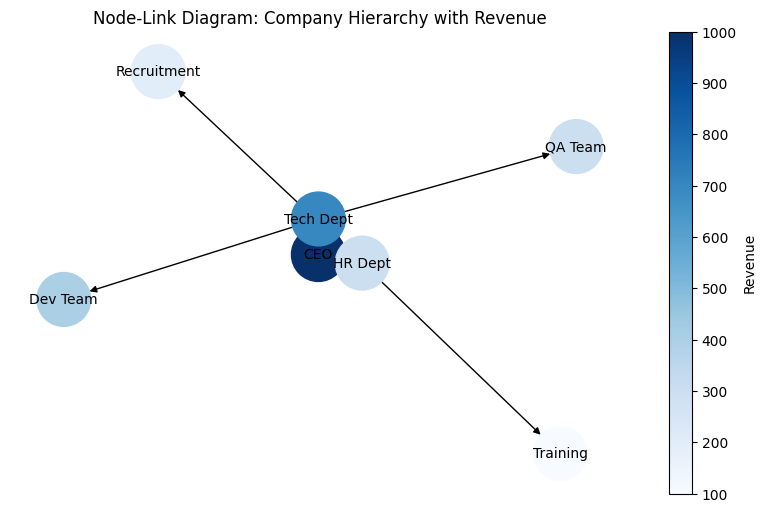

In [4]:
import networkx as nx
import matplotlib.pyplot as plt

# Simulated Company Hierarchy with revenue attribute
G = nx.DiGraph()

G.add_node("CEO", revenue=1000)
G.add_node("Tech Dept", revenue=700)
G.add_node("HR Dept", revenue=300)
G.add_node("Dev Team", revenue=400)
G.add_node("QA Team", revenue=300)
G.add_node("Recruitment", revenue=200)
G.add_node("Training", revenue=100)

edges = [
    ("CEO", "Tech Dept"),
    ("CEO", "HR Dept"),
    ("Tech Dept", "Dev Team"),
    ("Tech Dept", "QA Team"),
    ("HR Dept", "Recruitment"),
    ("HR Dept", "Training")
]

G.add_edges_from(edges)

# Get positions using layout
pos = nx.spring_layout(G, seed=42)

# Node color based on revenue
colors = [G.nodes[n]['revenue'] for n in G.nodes]

fig, ax = plt.subplots(figsize=(10, 6))

# Draw the graph on the Axes object
nx.draw(G, pos, with_labels=True, node_color=colors, cmap=plt.cm.Blues,
        node_size=1500, font_size=10, ax=ax)

# Create colorbar
sm = plt.cm.ScalarMappable(cmap=plt.cm.Blues)
sm.set_array(colors)
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label("Revenue")

plt.title("Node-Link Diagram: Company Hierarchy with Revenue")
plt.show()


Dataset: Simulated company hierarchy with 7 nodes and 6 edges. Each node has a revenue attribute.

Features used: Node name, parent–child relationship (edges), and revenue (color).

Observation: The Tech Department contributes more revenue than HR, with Dev and QA teams making up most of it.

2. Indented Tree (AST Visualization)

In [6]:
from anytree import Node, RenderTree


root = Node("-")
plus1 = Node("+", parent=root)
Node("1", parent=plus1)
Node("2", parent=plus1)

mult = Node("*", parent=root)
Node("3", parent=mult)

plus2 = Node("+", parent=mult)
div = Node("/", parent=plus2)
Node("7", parent=div)
Node("4", parent=div)

minus = Node("-", parent=plus2)
Node("5", parent=minus)
Node("7", parent=minus)

# Display tree
for pre, fill, node in RenderTree(root):
    print(f"{pre}{node.name}")


-
├── +
│   ├── 1
│   └── 2
└── *
    ├── 3
    └── +
        ├── /
        │   ├── 7
        │   └── 4
        └── -
            ├── 5
            └── 7


Dataset: Abstract Syntax Tree (AST) built from the math expression (1 + 2) - 3 * (7 / 4 + (5 - 7)).

Features: Nodes represent operations or operands. Structure follows post-order evaluation.

Observation: Tree reflects operator precedence (multiplication before subtraction), and grouping via brackets.

3. Treemap

In [7]:
import plotly.express as px
import pandas as pd

# Simulated data
data = {
    "Department": ["Tech", "Tech", "HR", "HR"],
    "Team": ["Dev", "QA", "Recruitment", "Training"],
    "Revenue": [400, 300, 200, 100]
}

df = pd.DataFrame(data)

fig = px.treemap(df, path=["Department", "Team"], values="Revenue",
                 color="Revenue", hover_data=["Revenue"],
                 color_continuous_scale="Blues")

fig.update_layout(title="Treemap: Team Revenue Breakdown by Department")
fig.show()


Dataset: Simulated team revenue in departments. 4 rows, 3 columns.

Features used: Department, Team, Revenue.

Observation: Tech → Dev team has the largest contribution, while HR → Training has the smallest.